In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_dir = "../smartvision_dataset/classification/train"
val_dir = "../smartvision_dataset/classification/val"
test_dir = "../smartvision_dataset/classification/test"

In [3]:
img_size = (224,224)
batch_size = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 1749 images belonging to 25 classes.
Found 375 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [4]:
num_classes = train_data.num_classes

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu",
                 kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs=base_model.input, outputs=output)

In [5]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3),
    ModelCheckpoint("../models/resnet50_best.h5", monitor="val_loss", save_best_only=True)
]

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
result = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0511 - loss: 4.7002

110/110 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.0726 - loss: 4.4126 - val_accuracy: 0.2560 - val_loss: 3.0804 - learning_rate: 1.0000e-04
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1737 - loss: 3.5370

110/110 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.2236 - loss: 3.3297 - val_accuracy: 0.4320 - val_loss: 2.5269 - learning_rate: 1.0000e-04
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3056 - loss: 2.9548

110/110 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.3270 - loss: 2.8650 - val_accuracy: 0.4773 - val_loss: 2.2622 - learning_rate: 1.0000e-04
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4040 - loss: 2.5696

110/110 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.4088 - loss: 2.5515 - val_accuracy: 0.5733 - val_loss: 2.1008 - learning_rate: 1.0000e-04
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4296 - loss: 2.4443

...

110/110 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.6535 - loss: 1.6277 - val_accuracy: 0.7120 - val_loss: 1.6584 - learning_rate: 1.0000e-04
Epoch 17/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 972ms/step - accuracy: 0.6879 - loss: 1.5320

110/110 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.6690 - loss: 1.5741 - val_accuracy: 0.7173 - val_loss: 1.6386 - learning_rate: 1.0000e-04
Epoch 18/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.7033 - loss: 1.4939

110/110 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.6792 - loss: 1.5361 - val_accuracy: 0.7147 - val_loss: 1.6298 - learning_rate: 1.0000e-04
Epoch 19/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 978ms/step - accuracy: 0.6709 - loss: 1.5443

110/110 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.6770 - loss: 1.5293 - val_accuracy: 0.7147 - val_loss: 1.6098 - learning_rate: 1.0000e-04
Epoch 20/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 989ms/step - accuracy: 0.6885 - loss: 1.4931

110/110 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.6838 - loss: 1.4951 - val_accuracy: 0.7253 - val_loss: 1.5924 - learning_rate: 1.0000e-04


In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.6941 - loss: 1.4948 - val_accuracy: 0.7093 - val_loss: 1.6016 - learning_rate: 3.0000e-05
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.7073 - loss: 1.4294 - val_accuracy: 0.7253 - val_loss: 1.5969 - learning_rate: 3.0000e-05
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7244 - loss: 1.3446

110/110 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.7261 - loss: 1.3200 - val_accuracy: 0.7387 - val_loss: 1.5589 - learning_rate: 3.0000e-05
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7677 - loss: 1.2223

110/110 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.7541 - loss: 1.2751 - val_accuracy: 0.7467 - val_loss: 1.5201 - learning_rate: 3.0000e-05
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7655 - loss: 1.2509

110/110 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.7621 - loss: 1.2317 - val_accuracy: 0.7547 - val_loss: 1.4997 - learning_rate: 3.0000e-05
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.7907 - loss: 1.1530 - val_accuracy: 0.7573 - val_loss: 1.5117 - learning_rate: 3.0000e-05
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.7987 - loss: 1.1059 - val_accuracy: 0.7440 - val_loss: 1.5267 - learning_rate: 3.0000e-05
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8217 - loss: 1.0308

110/110 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.8250 - loss: 1.0483 - val_accuracy: 0.7573 - val_loss: 1.4742 - learning_rate: 3.0000e-05
Epoch 9/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.8319 - loss: 1.0150 - val_accuracy: 0.7440 - val_loss: 1.5498 - learning_rate: 3.0000e-05
Epoch 10/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.8388 - loss: 0.9767 - val_accuracy: 0.7653 - val_loss: 1.5285 - learning_rate: 3.0000e-05
Epoch 11/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.8468 - loss: 0.9465 - val_accuracy: 0.7653 - val_loss: 1.5045 - learning_rate: 3.0000e-05
Epoch 12/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8854 - loss: 0.8494

110/110 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.8725 - loss: 0.8758 - val_accuracy: 0.7653 - val_loss: 1.4649 - learning_rate: 6.0000e-06
Epoch 13/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8713 - loss: 0.8804

110/110 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.8811 - loss: 0.8425 - val_accuracy: 0.7733 - val_loss: 1.4559 - learning_rate: 6.0000e-06
Epoch 14/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8655 - loss: 0.8769

110/110 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.8691 - loss: 0.8562 - val_accuracy: 0.7707 - val_loss: 1.4407 - learning_rate: 6.0000e-06
Epoch 15/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8812 - loss: 0.8372

110/110 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.8816 - loss: 0.8419 - val_accuracy: 0.7867 - val_loss: 1.4320 - learning_rate: 6.0000e-06
Epoch 16/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8892 - loss: 0.8151

110/110 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8908 - loss: 0.8227 - val_accuracy: 0.7867 - val_loss: 1.4254 - learning_rate: 6.0000e-06
Epoch 17/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8765 - loss: 0.8462 - val_accuracy: 0.7867 - val_loss: 1.4383 - learning_rate: 6.0000e-06
Epoch 18/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.8942 - loss: 0.8155 - val_accuracy: 0.7867 - val_loss: 1.4334 - learning_rate: 6.0000e-06
Epoch 19/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8931 - loss: 0.7967 - val_accuracy: 0.7813 - val_loss: 1.4370 - learning_rate: 6.0000e-06
Epoch 20/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.9005 - loss: 0.7833 - val_accuracy: 0.7760 - val_loss: 1.4337 - learning_rate: 1.2000e-06
Epoch 21/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.8959 - loss: 0.7969 - val_accuracy: 0.7787 - val_loss: 1.4343 - learning_rate: 1.2000e-06


- Train 90
- Test 80

In [9]:
test_loss, test_acc = model.evaluate(test_data)
print(test_acc)

24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 921ms/step - accuracy: 0.7920 - loss: 1.2204
0.7919999957084656


In [4]:
def prediction():
    model = models.load_model("../models/VGG16_best.h5")

    img_path = "../smartvision_dataset/detection/images/image_000002.jpg"
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array)

    class_indices = train_data.class_indices
    class_names = list(class_indices.keys())

    predicted_class = class_names[np.argmax(predictions)]

    return predicted_class

In [11]:
pred = prediction()
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


'person'

In [11]:
model = models.load_model("../models/resnet50_best.h5")
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes
print(classification_report(y_true, y_pred_classes, target_names=list(test_data.class_indices.keys())))

24/24 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step
               precision    recall  f1-score   support

     airplane       0.88      0.93      0.90        15
          bed       0.69      0.60      0.64        15
        bench       0.90      0.60      0.72        15
      bicycle       0.92      0.73      0.81        15
         bird       0.93      0.87      0.90        15
       bottle       0.86      0.80      0.83        15
         bowl       0.50      0.67      0.57        15
          bus       0.92      0.80      0.86        15
         cake       0.83      0.67      0.74        15
          car       0.70      0.93      0.80        15
          cat       0.67      0.93      0.78        15
        chair       0.88      1.00      0.94        15
        couch       0.60      0.40      0.48        15
          cow       0.82      0.93      0.88        15
          cup       0.71      0.67      0.69        15
          dog       0.70      0.47      0.56        15
     elephant       0.93 

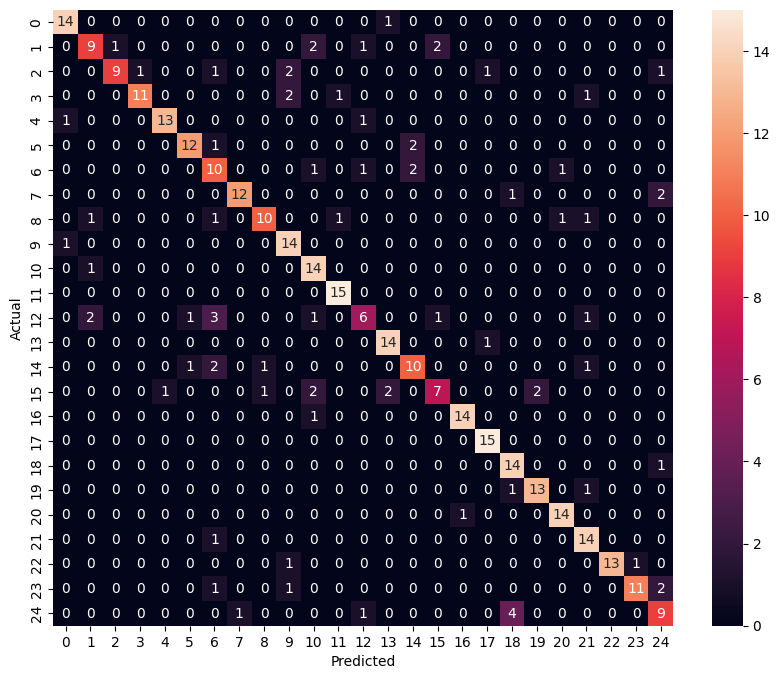

In [9]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()